<a href="https://colab.research.google.com/github/jahnavimala/EDA-Project/blob/main/Airbnb_Market_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ==========================================
# AIRBNB MARKET EDA PROJECT
# ==========================================

# Install:
# pip install kagglehub[pandas-datasets]
# pip install pandas numpy matplotlib seaborn

# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# ==========================================
# STEP 2: LOAD DATASET
# ==========================================

file_path = "AB_NYC_2019.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "dgomonov/new-york-city-airbnb-open-data",
    file_path
)

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

/tmp/ipykernel_8817/1638140436.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.

========== FIRST 5 ROWS ==========
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type 

In [6]:
# ==========================================
# STEP 3: BASIC EXPLORATION
# ==========================================

print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== DATASET INFO ==========")
print(df.info())

print("\n========== STATISTICS ==========")
print(df.describe())


========== DATASET SHAPE ==========
(48895, 16)

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_o

In [7]:
# ==========================================
# STEP 4: MISSING VALUES
# ==========================================

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())


# Fill numeric missing values
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

# Fill categorical missing values
categorical_cols = df.select_dtypes(include='object').columns
df[categorical_cols] = df[categorical_cols].fillna("Unknown")


========== MISSING VALUES ==========
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [8]:
# ==========================================
# STEP 5: REMOVE DUPLICATES
# ==========================================

print("\nDuplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicates: 0


In [9]:
# ==========================================
# STEP 6: TOP NEIGHBORHOODS
# ==========================================

print("\n========== TOP NEIGHBORHOODS ==========")
print(
    df['neighbourhood_group']
    .value_counts()
)


========== TOP NEIGHBORHOODS ==========
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64


In [10]:
# ==========================================
# STEP 7: PRICE ANALYSIS
# ==========================================

print("\nAverage Price:", df['price'].mean())

# Remove extreme outliers
df = df[df['price'] < 1000]


Average Price: 152.7206871868289


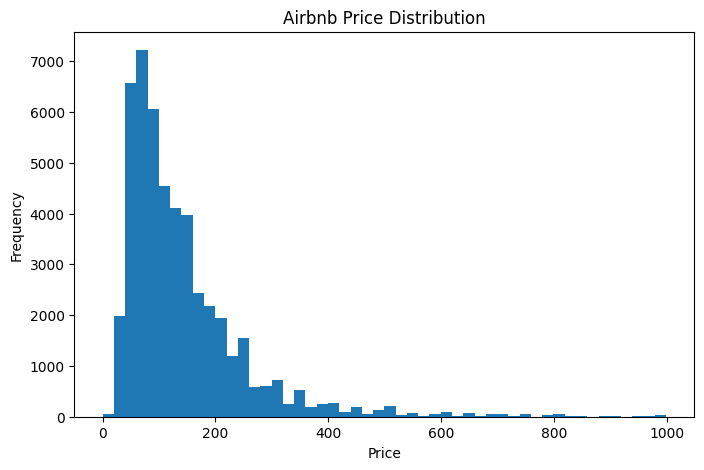

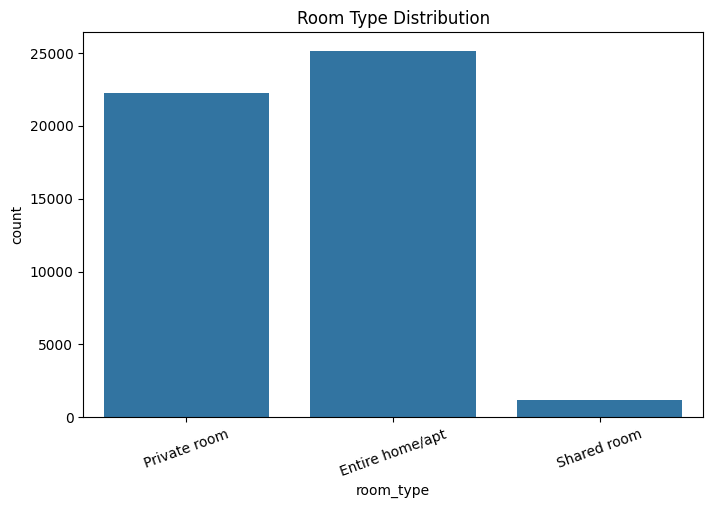

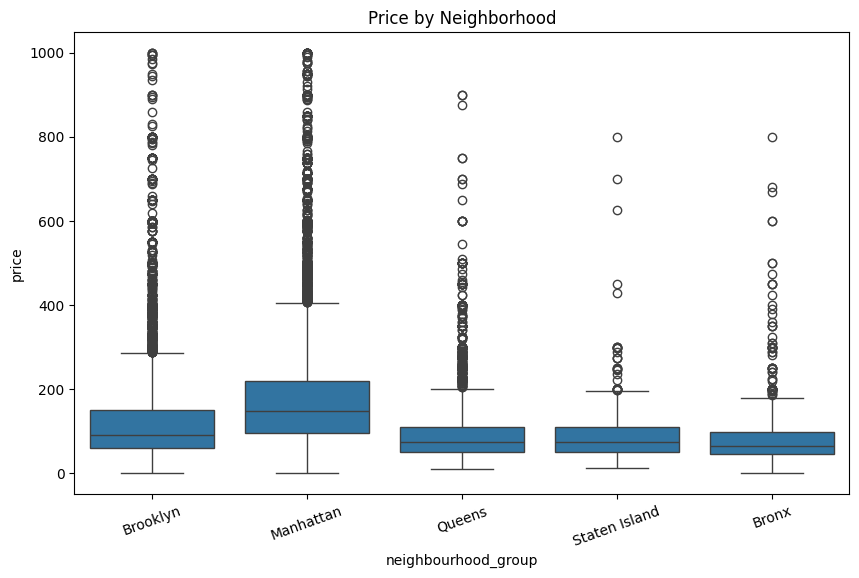

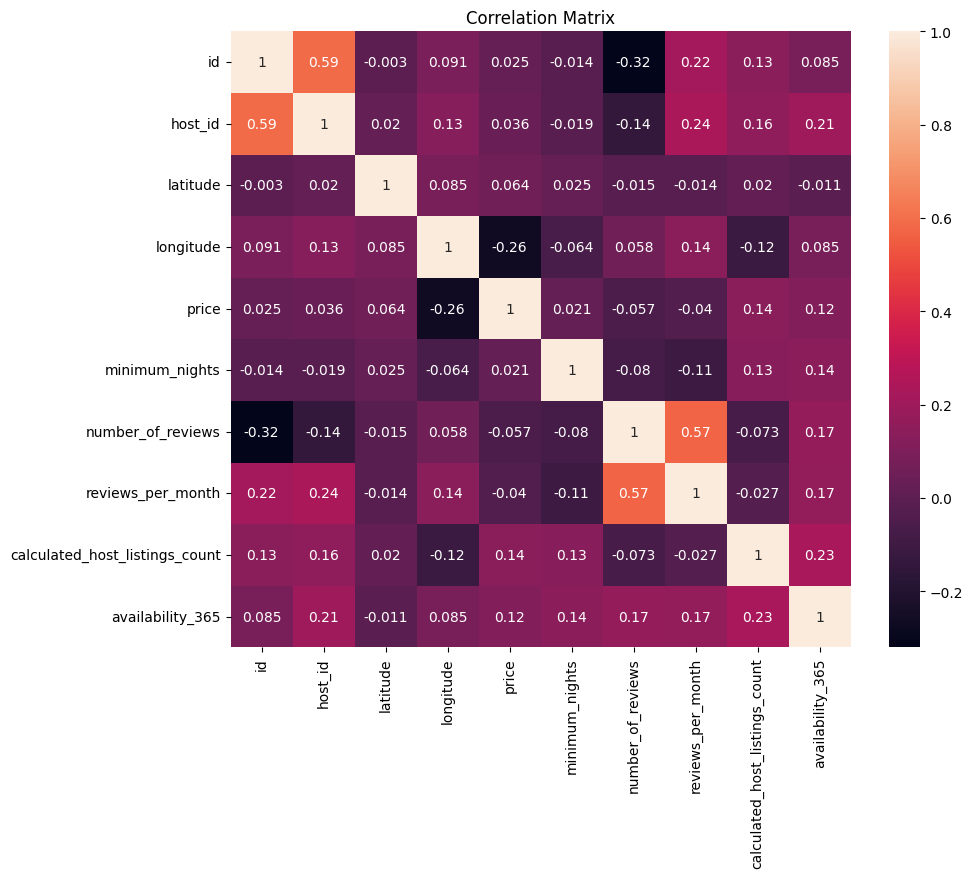

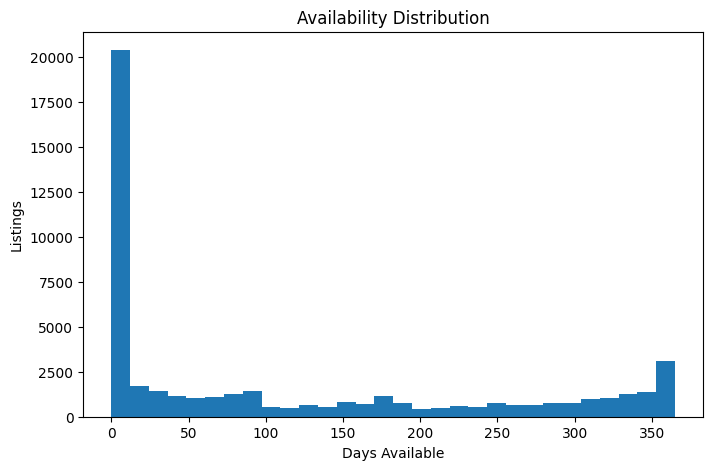

In [14]:
# ==========================================
# STEP 8: VISUALIZATIONS
# ==========================================

# Price Distribution
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=50)
plt.title("Airbnb Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()
print("\n")

# Room Type Count
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='room_type'
)
plt.title("Room Type Distribution")
plt.xticks(rotation=20)
plt.show()
print("\n")


# Neighborhood Price Analysis
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='neighbourhood_group',
    y='price'
)
plt.title("Price by Neighborhood")
plt.xticks(rotation=20)
plt.show()
print("\n")


# Correlation Heatmap
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()
print("\n")


# Availability Analysis
plt.figure(figsize=(8,5))
plt.hist(
    df['availability_365'],
    bins=30
)

plt.title("Availability Distribution")
plt.xlabel("Days Available")
plt.ylabel("Listings")
plt.show()
print("\n")

In [12]:
# ==========================================
# STEP 9: KEY INSIGHTS
# ==========================================

print("\n========== BUSINESS INSIGHTS ==========")

most_expensive = df.groupby(
    'neighbourhood_group'
)['price'].mean()

print("\nAverage Price by Area:")
print(most_expensive)

most_reviewed = df.sort_values(
    by='number_of_reviews',
    ascending=False
).head(10)

print("\nTop Reviewed Listings:")
print(
    most_reviewed[
        ['name', 'price', 'number_of_reviews']
    ]
)

print("\n========== FINAL INSIGHTS ==========")
print("1. Manhattan usually has higher listing prices.")
print("2. Entire homes cost more than shared rooms.")
print("3. Availability and reviews influence pricing.")
print("4. Location strongly impacts Airbnb revenue.")


========== BUSINESS INSIGHTS ==========

Average Price by Area:
neighbourhood_group
Bronx             84.443526
Brooklyn         117.235564
Manhattan        177.366747
Queens            94.528038
Staten Island     96.148649
Name: price, dtype: float64

Top Reviewed Listings:
                                                    name  price  \
11759                            Room near JFK Queen Bed     47   
2031                          Great Bedroom in Manhattan     49   
2030                      Beautiful Bedroom in Manhattan     49   
2015                        Private Bedroom in Manhattan     49   
13495                            Room Near JFK Twin Beds     47   
10623                  Steps away from Laguardia airport     46   
1879            Manhattan Lux Loft.Like.Love.Lots.Look !     99   
20403  Cozy Room Family Home LGA Airport NO CLEANING FEE     48   
4870                  Private brownstone studio Brooklyn    160   
471                      LG Private Room/Family Frien